# train

## import

In [95]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from stable_baselines3 import PPO
from multiprocessing import Pool
import multiprocessing as mp
from matplotlib import pyplot as plt
import numpy as np


## train

In [126]:
food_reward_list = [1000, 1100, 1200, 1300, 1400]
att_coeff = 0.087213 #0.087213
att_temp = 0.25 # 0.25
penalty_cost = -30 #  -30
time_in_game_reward = 0. # old 0
# num_epochs = 11
# seed_value = 1

## food reward as a paramter input

In [127]:
# baseline test
task=AF()
task.food_reward=1000
task.attention_cost_coeff=att_coeff
task.attention_cost_temp=att_temp
task.penalty_cost=penalty_cost
task.time_in_game_reward=time_in_game_reward
model = PPO('MlpPolicy', task, verbose=1, device='cpu')
model.learn(total_timesteps=9999/25*3600*1)
# model.save('ycstore/8hrtest')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.94     |
|    ep_rew_mean     | -20.1    |
| time/              |          |
|    fps             | 797      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.38        |
|    ep_rew_mean          | -29.3       |
| time/                   |             |
|    fps                  | 584         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014606686 |
|    clip_fraction        | 0.216       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.000168    |
|    learning_rate        | 0.

KeyboardInterrupt: 

In [137]:
from collections import defaultdict
history_r=[]

for _ in range(5):
    t=0
    total_r=0
    x=task.reset()  
    done=False
    while not done: 
        # model.predict(x)
        a,_=model.predict(x,deterministic=True)
        x, r, done, _ = task.step(a)
        # print(x, r,task.food_reward)
        t+=1
        total_r+=r
    print(total_r)
# history_r 
    # print(task.food_reward)


0.0
0.0
0.0
0.0
0.0


In [76]:
task=AFR()
task.food_reward_list=food_reward_list
model = PPO('MlpPolicy', task, verbose=1, device='cpu')
model.learn(total_timesteps=9999/25*3600*1)
# model.save('ycstore/8hrtest')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.93     |
|    ep_rew_mean     | -45.6    |
| time/              |          |
|    fps             | 765      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.52        |
|    ep_rew_mean          | -45.6       |
| time/                   |             |
|    fps                  | 570         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013881185 |
|    clip_fraction        | 0.192       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.000308    |
|    learning_rate        | 0.

KeyboardInterrupt: 

## load and eval

In [70]:
task=AFR()
task.food_reward_list=food_reward_list
model = PPO.load(f'ycstore/8hrtest', env=task, device='cpu')

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [71]:
from collections import defaultdict
history_r=defaultdict(list)

for _ in range(5*999):
    t=0
    total_r=0
    x=task.reset()  
    done=False
    while not done: 
        # model.predict(x)
        a,_=model.predict(x)
        x, r, done, _ = task.step(a)
        # print(x, r,task.food_reward)
        t+=1
        total_r+=r
    history_r[task.food_reward].append(total_r/t)  
    # print(task.food_reward)


KeyboardInterrupt: 

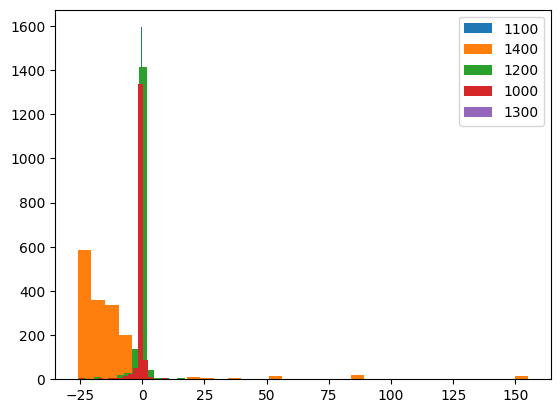

In [53]:
for food_reward,reward_rate in history_r.items():
    plt.hist(reward_rate,bins=33, label=food_reward)
    # plt.title(food_reward)
    # plt.show()
plt.legend()
    


avalible reward conditions [1000, 1100, 1400, 1300, 1200]


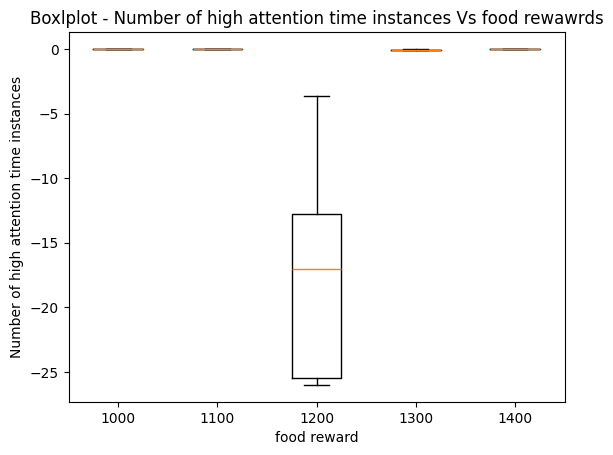

In [74]:
plt.figure()
thisdata=[]
thisx=[]
for food_reward,reward_rate in history_r.items():
    thisx.append(food_reward)
    thisdata.append(reward_rate)

print('avalible reward conditions',thisx)
plt.boxplot(thisdata, showfliers=False, positions=np.arange(5)+1)
plt.xticks([ind+1 for ind in range(len(food_reward_list))], [str(food_reward) for food_reward in food_reward_list])
plt.xlabel('food reward')
plt.ylabel(f'Number of high attention time instances')
plt.title(f'Boxlplot - Number of high attention time instances Vs food rewawrds')
plt.show()